# Parity asymmetry, $R^{\ell_\mathrm{max}}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import sys
from scipy.special import legendre
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sys.path.insert(1, '../../scripts')
import CMBanom

In [2]:
# Parameters
Nside = 128
lmax_R = 60
load_stats_from_cluster = False

if load_stats_from_cluster: Nsims = 100000
else:                       Nsims = 1000

In [3]:
# Directories
sims_dir  = '../../data/sims/sims_1k/'
real_dir  = "../../data/real/"
stats_dir = "../../data/stats/"

# Planck maps  
names_Planck  = ["commander_nside_128", "nilc_nside_128", "sevem_nside_128", "smica_nside_128", "v7_70GHz_nside_128",     "v7_94GHz_nside_128", "v7_100GHz_nside_128", "v7_143GHz_nside_128"]
labels_Planck = [r"$\mathrm{Commander}$", r"$\mathrm{NILC}$", r"$\mathrm{SEVEM}$", r"$\mathrm{SMICA}$", r"$70\, \mathrm{GHz}$", r"$94\, \mathrm{GHz}$", r"$100\, \mathrm{GHz}$", r"$143\, \mathrm{GHz}$"]
colors_Planck = [  "tab:red", "teal",  "navy",  "gold", "tab:red",    "teal",   "navy",   "gold"]
lss_Planck    = [       "--",   "--",    "--",    "--",       "-",       "-",      "-",      "-"]
color_qml     = "green"
label_qml     = r"$\mathrm{Public\ QML-}C_\ell$"
Nmaps = len(names_Planck)
index_Planck  = 0
index_Hayley  = 6

# Masks
names_mask  = [              "fullsky",                "stdmask",                  "commask"]
labels_mask = [r"$\mathrm{Full\ sky}$", r"$\mathrm{Std.\ mask}$", r"$\mathrm{Common\ mask}$"]
colors_mask = [             "tab:blue",                   "navy",                "firebrick"]
Nmasks = len(names_mask)

# Cls
fn_cl_theory = "COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt"
fn_cl_qml    = "COM_PowerSpect_CMB-TT-full_R3.01.txt"

In [4]:
# Font
plt.rc('font',**{'family':'Helvetica','size':20})
plt.rc('text', usetex=True)
font = {'family':'Helvetica',
        'color' : 'black',
        'size'  :  20}

In [5]:
# Same l-range for all Cls
lmax = 384
ll = np.arange(lmax)

In [6]:
# Load pixel window fct. & beam (smoothing window fct.)
cl_wf = CMBanom.get_cl_wf_factor(Nside)

In [7]:
# Load theory Cl used to generate (begins with l=2)
dl_theory = np.append(np.zeros(2), np.loadtxt(real_dir+fn_cl_theory, skiprows=1).T[1])[:lmax]

In [8]:
# Load Planck Cl (begins with l=0) and correct window fcts. and units, shape: (Nmasks, Nmaps, lmax)
cl_Planck = np.array([[np.loadtxt(real_dir+"cl_"+names_Planck[n]+"_"+names_mask[m]+".txt").T[1] for n in range(Nmaps)] for m in range(Nmasks)])
for m in range(Nmasks):
    cl_Planck[m] *= cl_wf

In [9]:
# Load QML Cl's (begins with l=2)
dl_qml = np.loadtxt(real_dir+fn_cl_qml).T[1][:lmax-2]
cl_qml = np.append(np.zeros(2), dl_qml/ll[2:]/(1+ll[2:])*2*np.pi)

In [10]:
# Get sim envelope
if load_stats_from_cluster:
    mean_cls = np.array([np.loadtxt(stats_dir+"cls_mean_perc_"+names_mask[m]+".npy")[0] for m in range(Nmasks)])
    perc_68_lower = np.array([np.loadtxt(stats_dir+"cls_mean_perc_"+names_mask[m]+".npy")[1] for m in range(Nmasks)])
    perc_68_upper = np.array([np.loadtxt(stats_dir+"cls_mean_perc_"+names_mask[m]+".npy")[2] for m in range(Nmasks)])
    perc_95_lower = np.array([np.loadtxt(stats_dir+"cls_mean_perc_"+names_mask[m]+".npy")[3] for m in range(Nmasks)])
    perc_95_upper = np.array([np.loadtxt(stats_dir+"cls_mean_perc_"+names_mask[m]+".npy")[4] for m in range(Nmasks)])
else: 
    cls = np.zeros((Nmasks, Nsims, lmax))
    for m in range(Nmasks):
        cls[m] = CMBanom.load_cls(sims_dir, names_mask[m], Nsims, cl_wf)
    mean_cls = np.mean(cls, axis=1)
    std_cls = np.std(cls, axis=1)
    perc_68_lower = np.percentile(cls, (100-68.27)/2, axis=1)
    perc_68_upper = np.percentile(cls, 68.27+(100-68.27)/2, axis=1)
    perc_95_lower = np.percentile(cls, (100-95.45)/2, axis=1)
    perc_95_upper = np.percentile(cls, 95.45+(100-95.45)/2, axis=1)

## Plot $C_\ell$'s

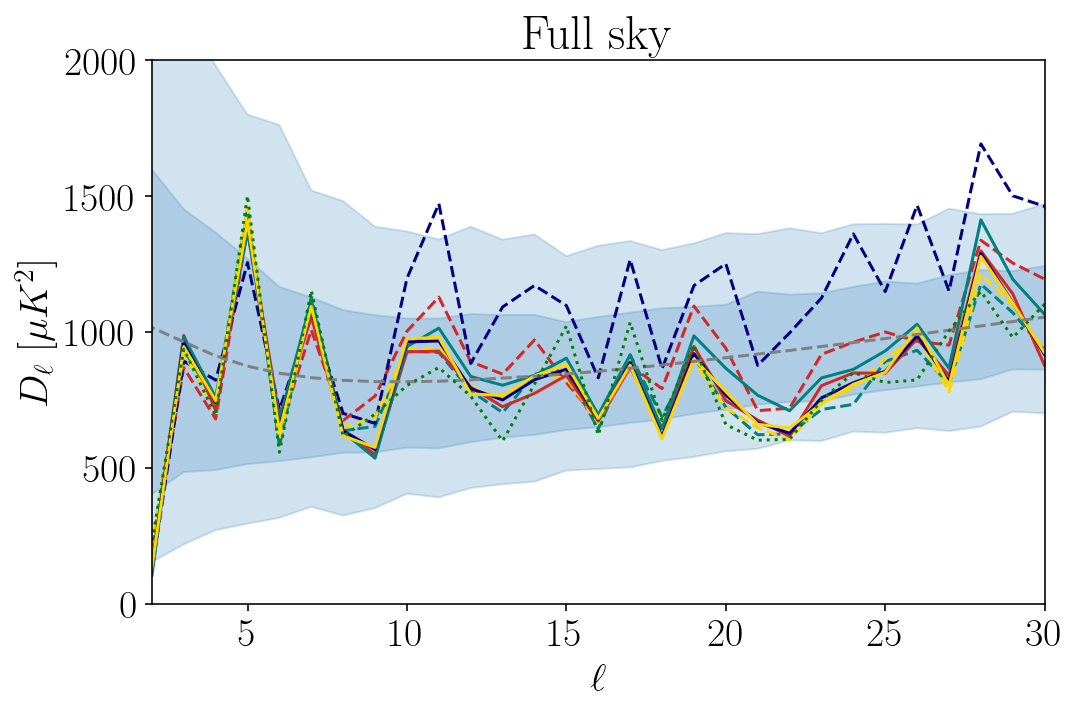

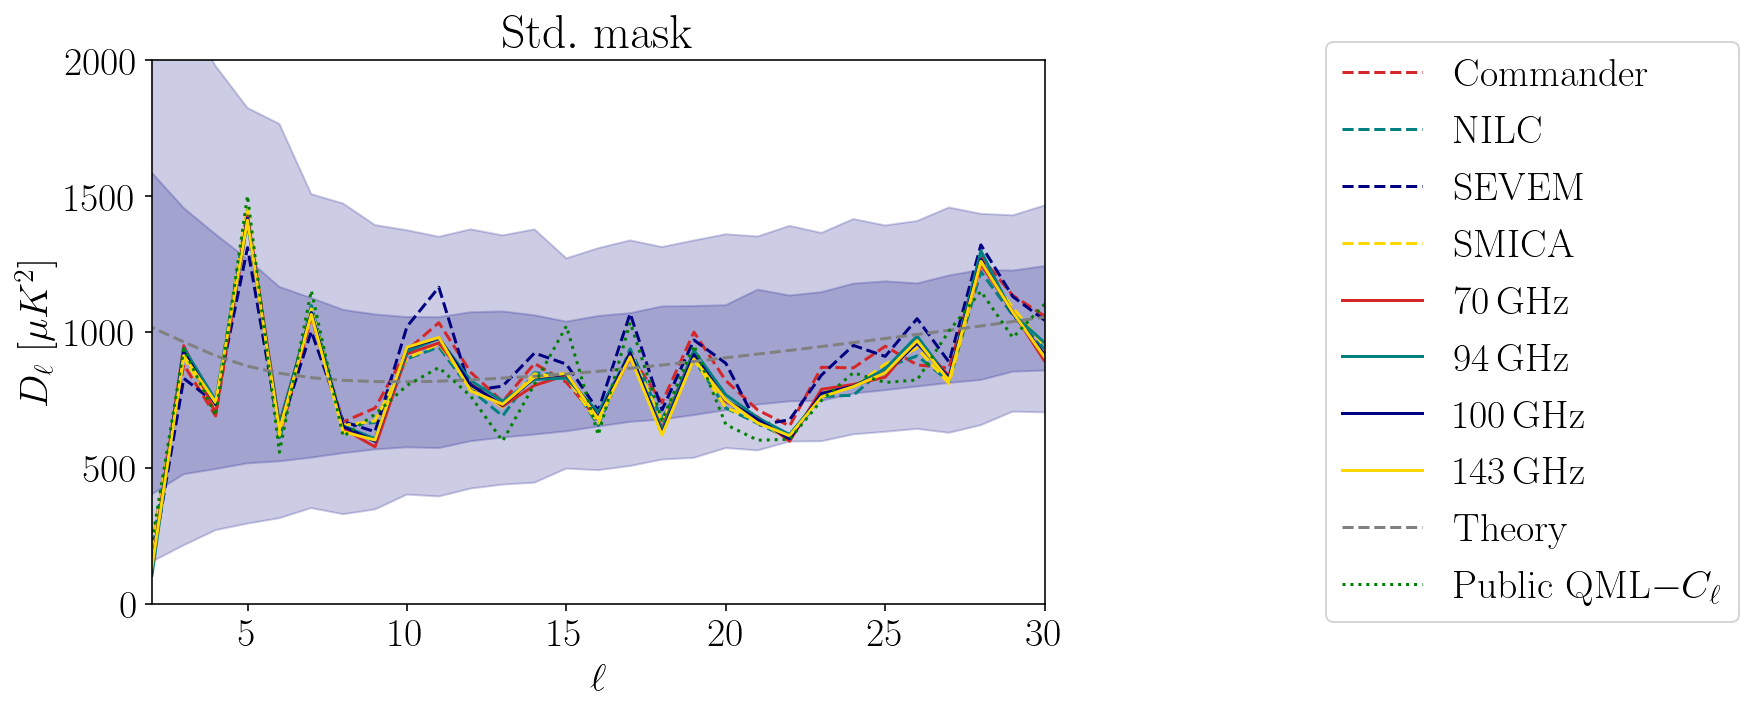

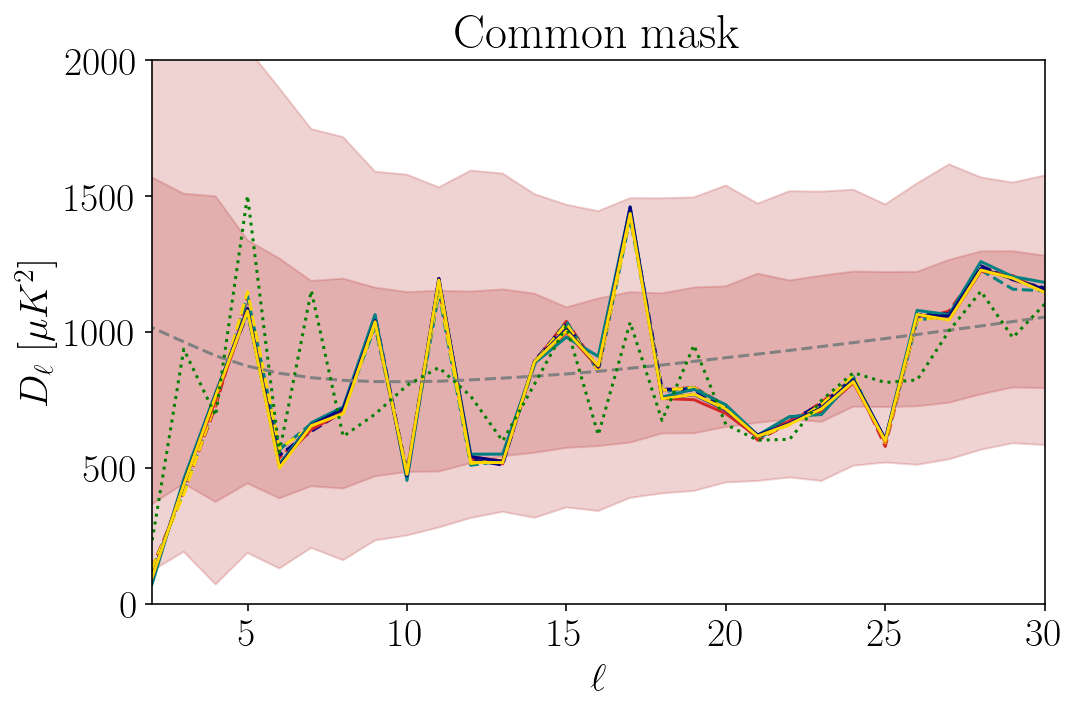

In [11]:
for m in range(Nmasks):
    fig = plt.figure(figsize=(8, 5))
    for n in range(Nmaps):
        plt.plot(ll, ll*(ll+1)*cl_Planck[m][n]/(2*np.pi), label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    plt.plot(ll, dl_theory, label=r"$\mathrm{Theory}$", color="grey", ls="--")
    plt.plot(ll, ll*(ll+1)*cl_qml/(2*np.pi), label=label_qml, color=color_qml, ls=":")
    plt.fill_between(ll, ll*(ll+1)/(2*np.pi)*perc_68_lower[m],   ll*(ll+1)/(2*np.pi)*perc_68_upper[m],   alpha= 0.2, color=colors_mask[m])
    plt.fill_between(ll, ll*(ll+1)/(2*np.pi)*perc_95_lower[m],   ll*(ll+1)/(2*np.pi)*perc_95_upper[m],   alpha= 0.2, color=colors_mask[m])
    
    plt.ylabel(r"$D_\ell\ [\mu K^2]$")
    plt.xlabel(r"$\ell$")
    plt.xlim(2,30)
    plt.ylim(0,2000)
    plt.title(labels_mask[m])
    #plt.legend(loc="lower right")
    if m==1: plt.legend(loc='center right', bbox_to_anchor=(1.8, 0.5))
    plt.savefig(f"Cl_{names_mask[m]}.pdf", format="PDF")
    plt.show()

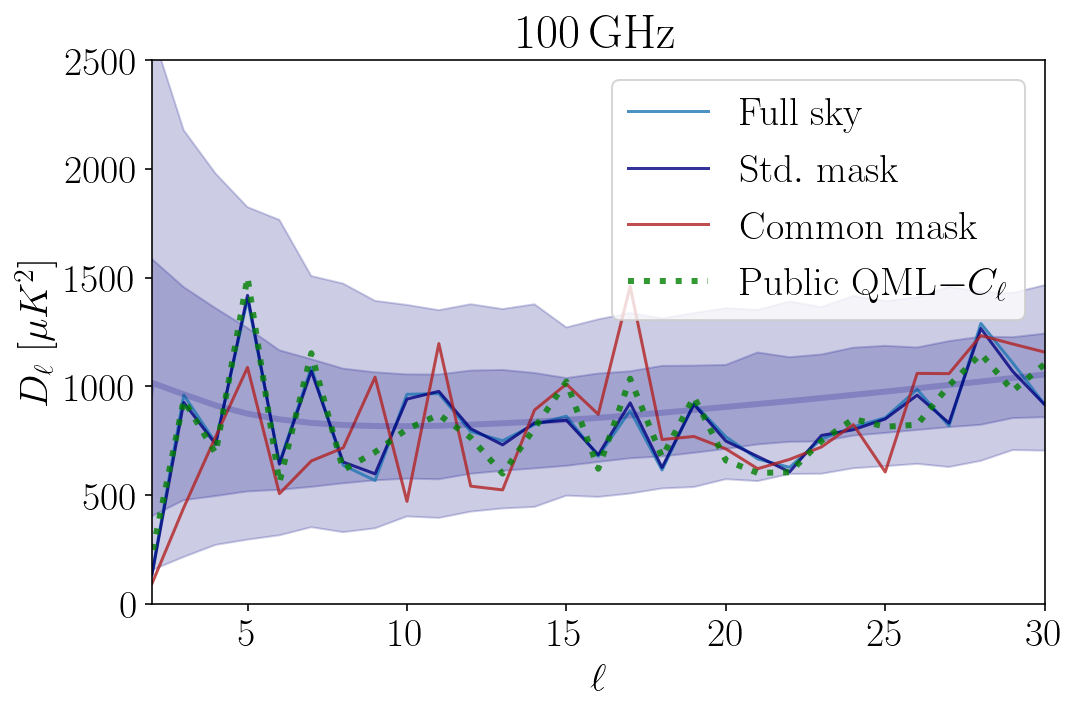

In [12]:
fig = plt.figure(figsize=(8, 5))
plt.title(labels_Planck[index_Hayley])
for m in [0, 1, 2]:
    plt.plot(ll, ll*(ll+1)*cl_Planck[m][index_Hayley]/(2*np.pi), color=colors_mask[m],  ls="-", alpha=0.8, label=labels_mask[m])
m = 1
plt.fill_between(ll, ll*(ll+1)/(2*np.pi)*perc_68_lower[m],   ll*(ll+1)/(2*np.pi)*perc_68_upper[m],   alpha= 0.2, color=colors_mask[m])
plt.fill_between(ll, ll*(ll+1)/(2*np.pi)*perc_95_lower[m],   ll*(ll+1)/(2*np.pi)*perc_95_upper[m],   alpha= 0.2, color=colors_mask[m])
   
plt.plot(ll, dl_theory, color=colors_mask[m], ls="-", alpha=0.2, lw=3)
plt.plot(ll, ll*(ll+1)*cl_qml/(2*np.pi), color=color_qml, ls=":", alpha=0.8, lw=3, label=label_qml)
plt.ylabel(r"$D_\ell\ [\mu K^2]$")
plt.xlabel(r"$\ell$")
plt.xlim(2,30)
plt.ylim(0,2500)
plt.legend(loc="upper right")
plt.savefig("Cl_zoom_in.pdf", format="PDF")
plt.show()

## Compute $R^{\ell_\mathrm{max}}$

$$R(\ell_\mathrm{max}) = \frac{D_+(\ell_\mathrm{max})}{D_-(\ell_\mathrm{max})}$$

where 
$$D_{+,-} = \frac{1}{\ell^{+,-}_\mathrm{tot}} \sum_{\ell = 2(+,-)}^{\ell_\mathrm{max}} \frac{\ell(\ell+1)}{2\pi}\ C_\ell$$

In [13]:
# Compute R for real maps
R_Planck = np.array([[[CMBanom.get_Rlmax(cl_Planck[m][n], lmax=l) for l in range(lmax_R)] for n in range(Nmaps)] for m in range(Nmasks)])
R_Planck_qml = [CMBanom.get_Rlmax(cl_qml, lmax=l) for l in range(lmax_R)]

In [14]:
# Compute R for sims
if load_stats_from_cluster:
    R_sims = np.array([np.loadtxt(stats_dir+f"R_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)])
else:
    R_sims = np.array([[[CMBanom.get_Rlmax(cls[m][n], lmax=l) for l in range(lmax_R)] for n in range(Nsims)] for m in range(Nmasks)])
std_R_sims = np.std(R_sims, axis=1)
mean_R_sims = np.mean(R_sims, axis=1)

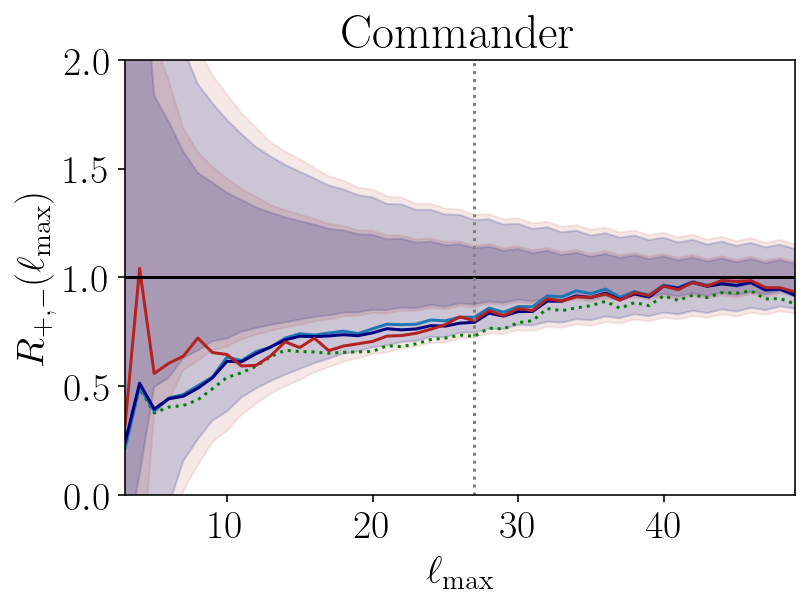

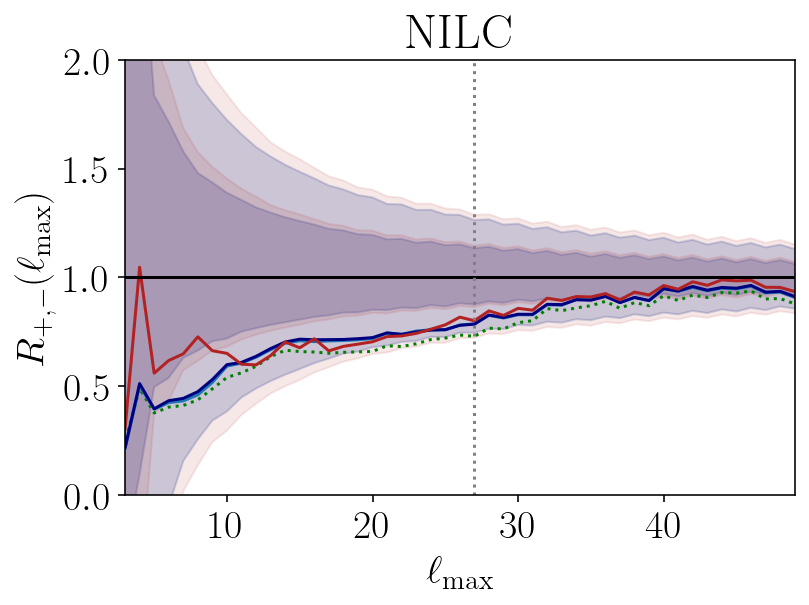

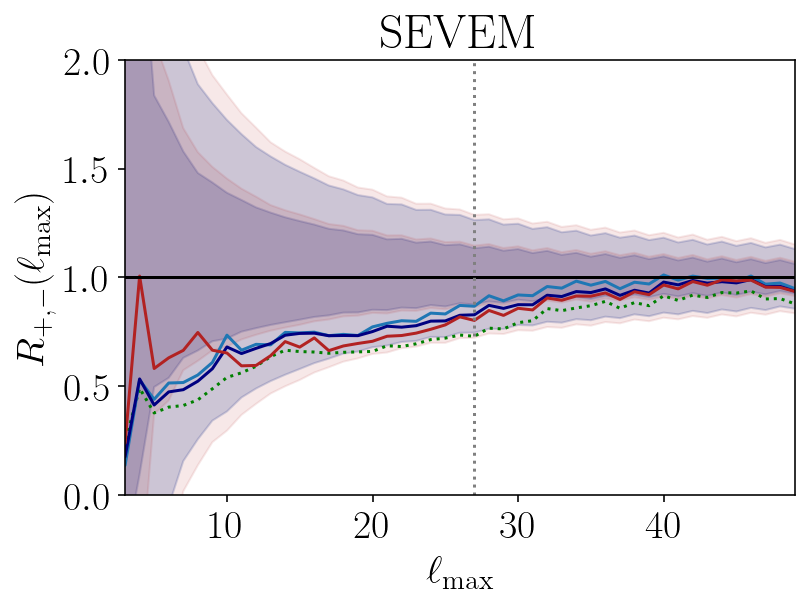

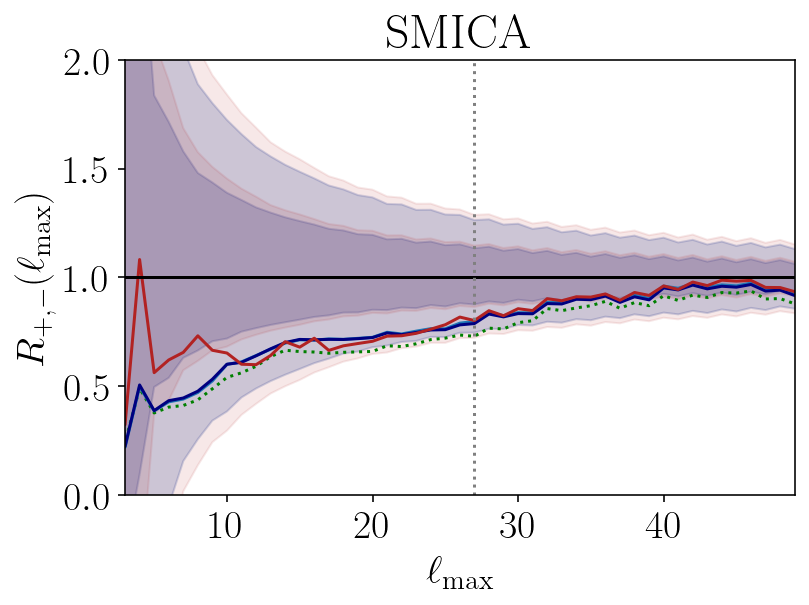

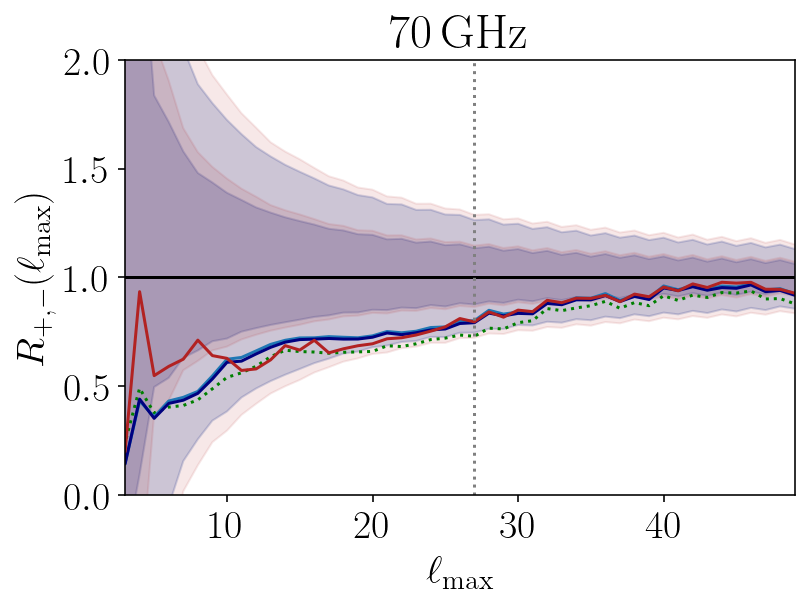

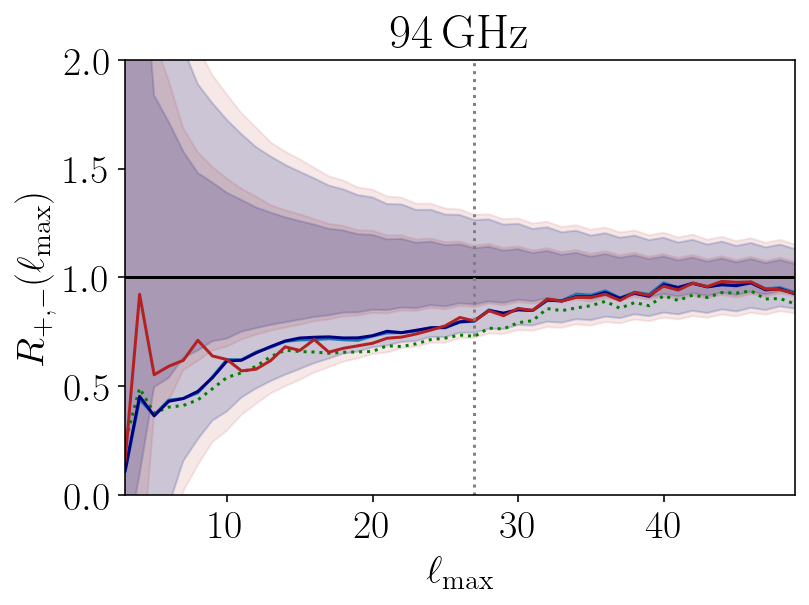

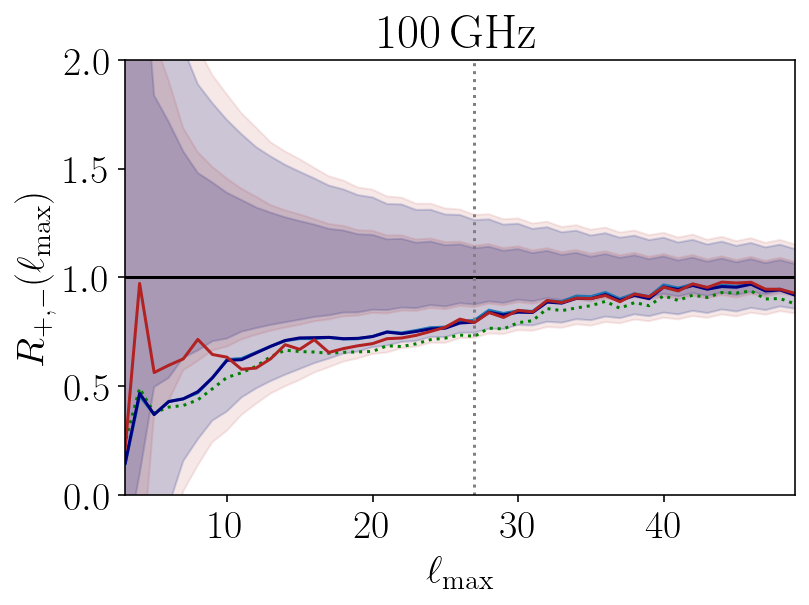

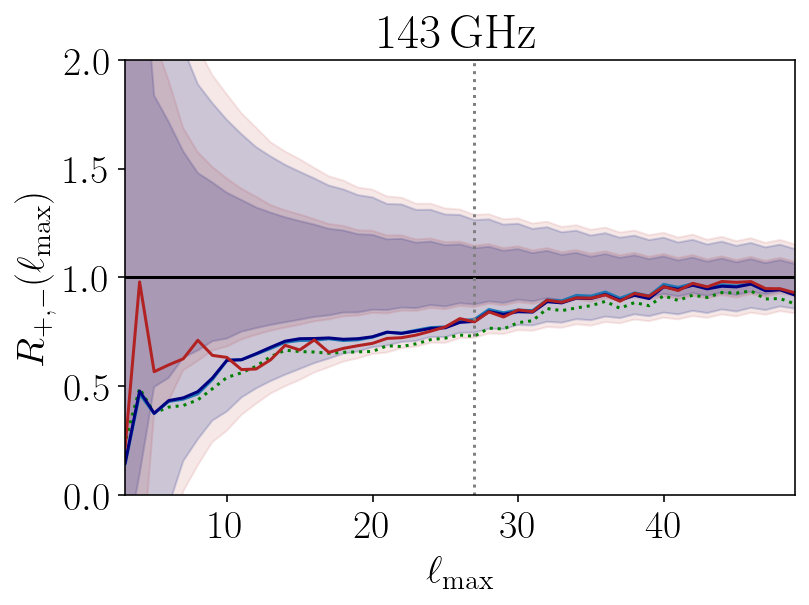

In [15]:
lmaxs = range(lmax_R)
for n in range(Nmaps):
    plt.title(labels_Planck[n])
    plt.plot(lmaxs, R_Planck_qml, label=label_qml, color=color_qml, ls=":")
    for m in range(Nmasks):
        plt.plot(lmaxs, R_Planck[m][n], label=labels_mask[m], color=colors_mask[m])
        plt.fill_between(lmaxs, mean_R_sims[m]-std_R_sims[m], mean_R_sims[m]+std_R_sims[m], color=colors_mask[m], alpha=0.1)
        plt.fill_between(lmaxs, mean_R_sims[m]-2*std_R_sims[m], mean_R_sims[m]+2*std_R_sims[m], color=colors_mask[m], alpha=0.1)
    plt.axhline(1, color="black")
    plt.xlabel(r"$\ell_\mathrm{max}$")
    plt.ylabel(r"$R_{+,-}(\ell_\mathrm{max})$")
    plt.xlim(3,49)
    plt.ylim(0,2)
    plt.axvline(27, color="grey", ls=":")
    #plt.legend()
    plt.show()

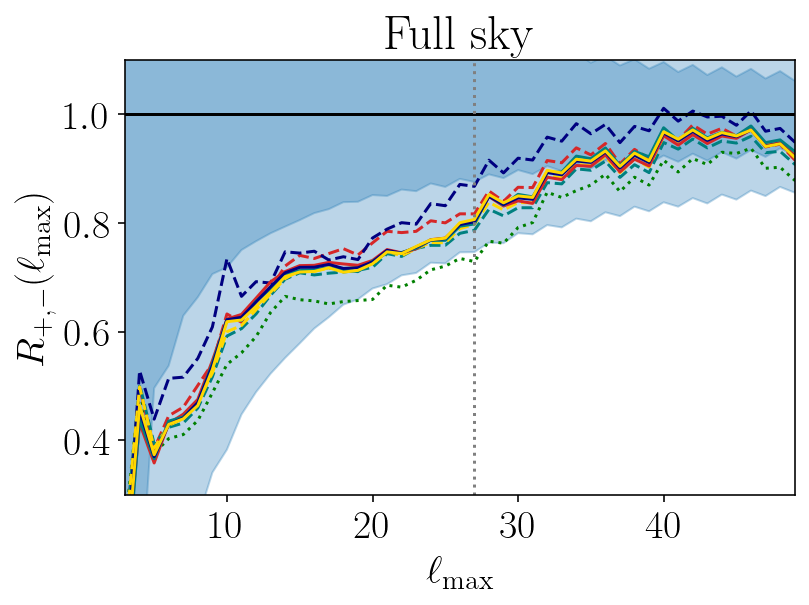

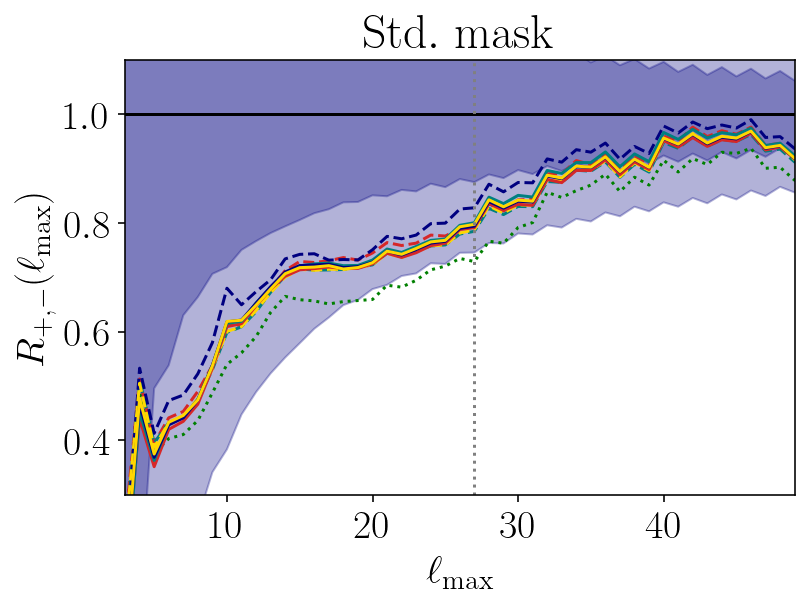

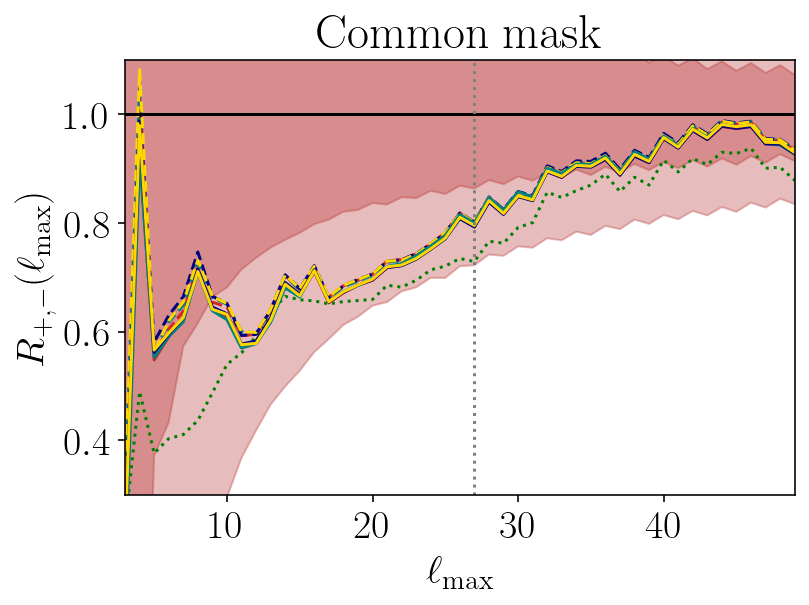

In [16]:
for m in range(Nmasks):
    plt.title(labels_mask[m])
    plt.plot(lmaxs, R_Planck_qml, label=label_qml, color=color_qml, ls=":")
    for n in range(Nmaps):
        plt.plot(lmaxs, R_Planck[m][n], label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    plt.fill_between(lmaxs, mean_R_sims[m]-std_R_sims[m], mean_R_sims[m]+std_R_sims[m], color=colors_mask[m], alpha=0.3)
    plt.fill_between(lmaxs, mean_R_sims[m]-2*std_R_sims[m], mean_R_sims[m]+2*std_R_sims[m], color=colors_mask[m], alpha=0.3)
    plt.axhline(1, color="black")
    plt.xlabel(r"$\ell_\mathrm{max}$")
    plt.ylabel(r"$R_{+,-}(\ell_\mathrm{max})$")
    plt.xlim(3,49)
    plt.ylim(0.3,1.1)
    plt.axvline(27, color="grey", ls=":")
    #plt.legend(loc="lower right")
    plt.show()

## Compute p-values

In [17]:
p_Planck = np.array([[[CMBanom.pval_lower(R_Planck[m][n][l], R_sims[m].T[l]) for l in lmaxs] for n in range(Nmaps)] for m in range(Nmasks)])
p_Planck_qml = np.array([CMBanom.pval_lower(R_Planck_qml[l], R_sims[0].T[l]) for l in lmaxs])

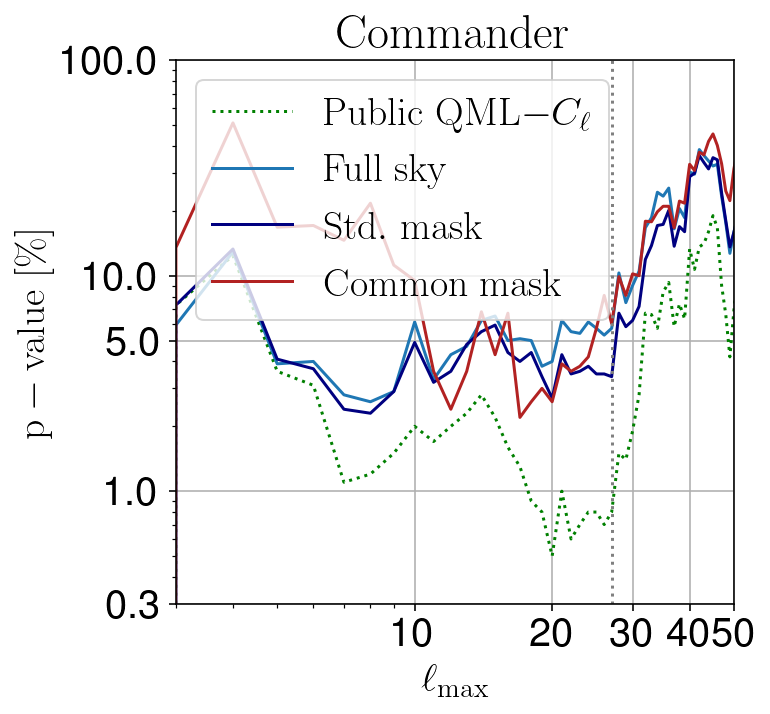

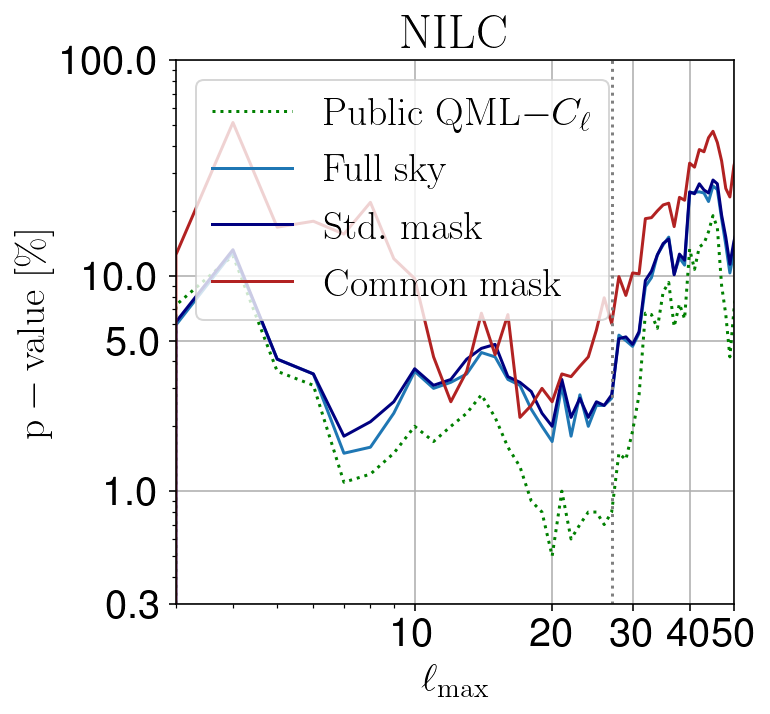

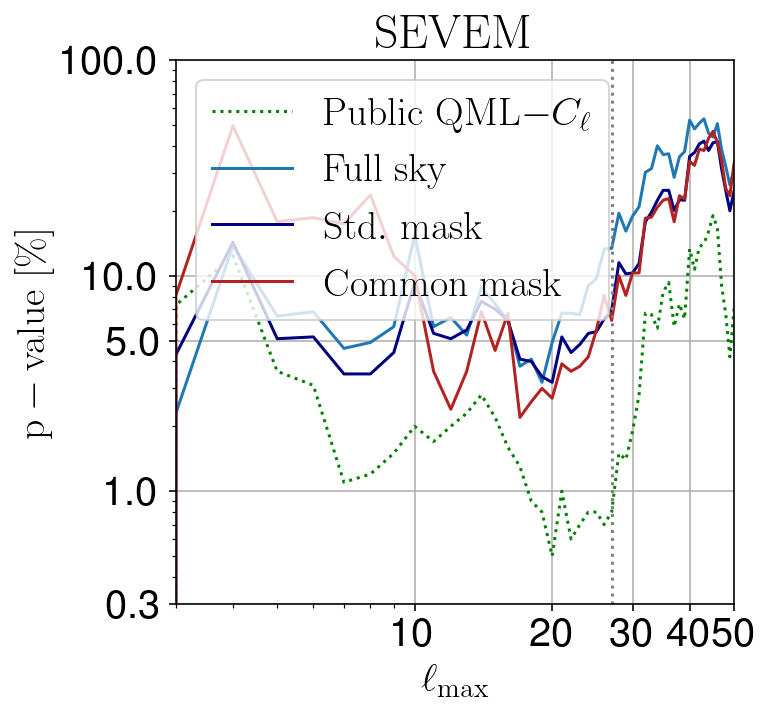

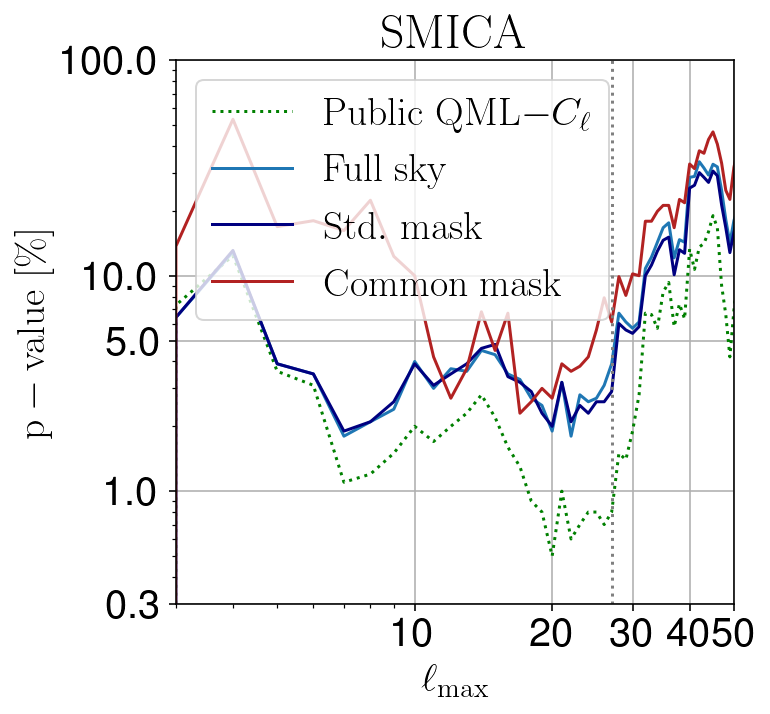

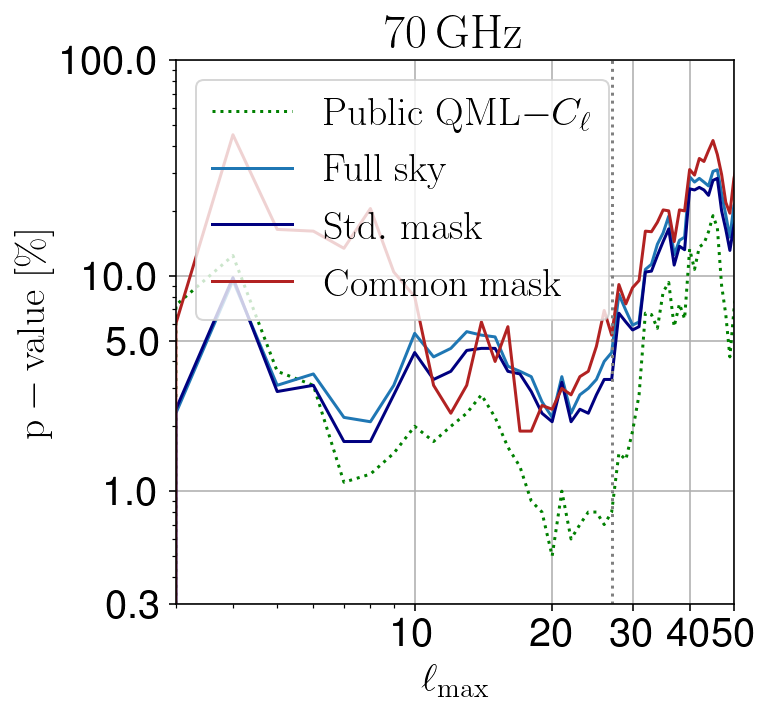

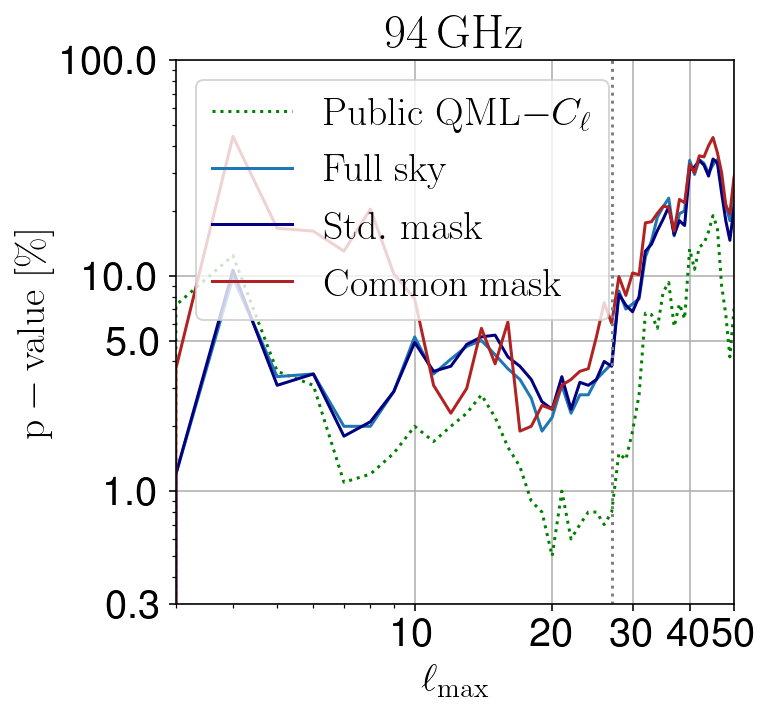

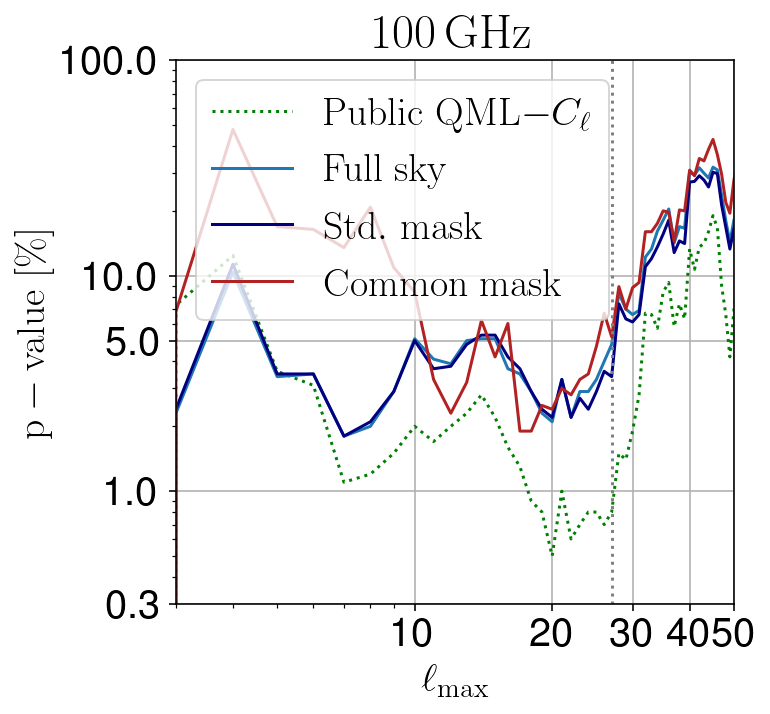

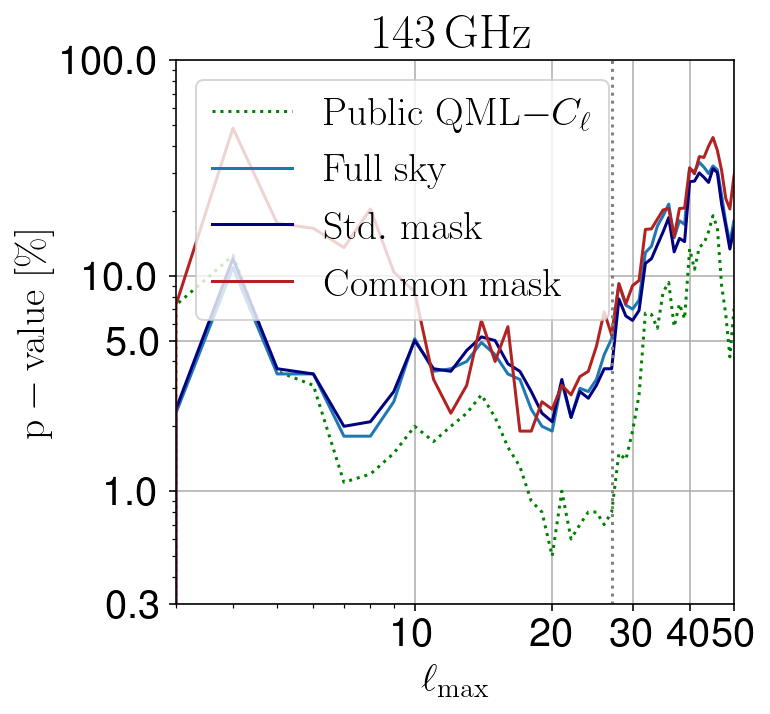

In [18]:
for n in range(Nmaps):
    plt.figure(figsize=(5,5))
    plt.title(labels_Planck[n])
    plt.loglog(lmaxs, 100*p_Planck_qml, label=label_qml, color=color_qml, ls=":")
    for m in range(Nmasks):
        plt.loglog(lmaxs, 100*p_Planck[m][n], label=labels_mask[m], color=colors_mask[m])
    plt.xlabel(r"$\ell_\mathrm{max}$")
    plt.ylabel(r"$\mathrm{p-value}\ [\%]$")
    plt.xlim(3,49)
    plt.xticks([10, 20, 30, 40, 50], labels=[10, 20, 30, 40, 50])
    plt.yticks([0.3, 1.0, 5.0, 10.0, 100.0], labels=[0.3, 1.0, 5.0, 10.0, 100.0])
    plt.axvline(27, color="grey", ls=":")
    plt.grid()
    plt.legend()
    plt.show()

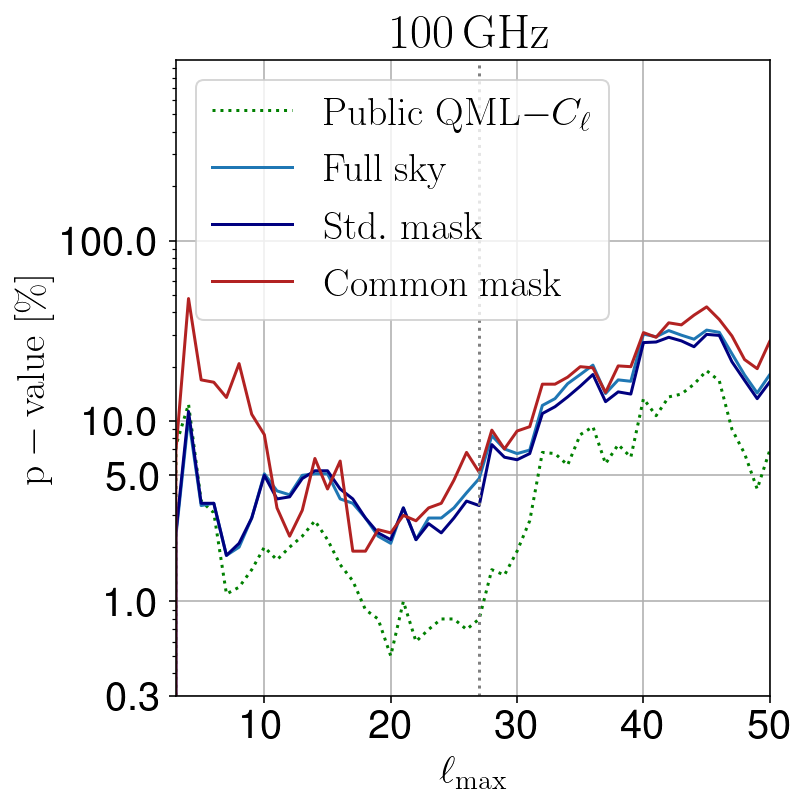

In [19]:
plt.figure(figsize=(6,6))
plt.title(labels_Planck[index_Hayley])
plt.semilogy(lmaxs, 100*p_Planck_qml, label=label_qml, color=color_qml, ls=":")
for m in range(Nmasks):
    plt.semilogy(lmaxs, 100*p_Planck[m][index_Hayley], label=labels_mask[m], color=colors_mask[m])
plt.xlabel(r"$\ell_\mathrm{max}$")
plt.ylabel(r"$\mathrm{p-value}\ [\%]$")
plt.xlim(3,49)
plt.ylim(0.3, 1000)
plt.xticks([10, 20, 30, 40, 50], labels=[10, 20, 30, 40, 50])
plt.yticks([0.3, 1.0, 5.0, 10.0, 100.0], labels=[0.3, 1.0, 5.0, 10.0, 100.0])
plt.axvline(27, color="grey", ls=":")
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("R_p(lmax).pdf", format="PDF")
plt.show()

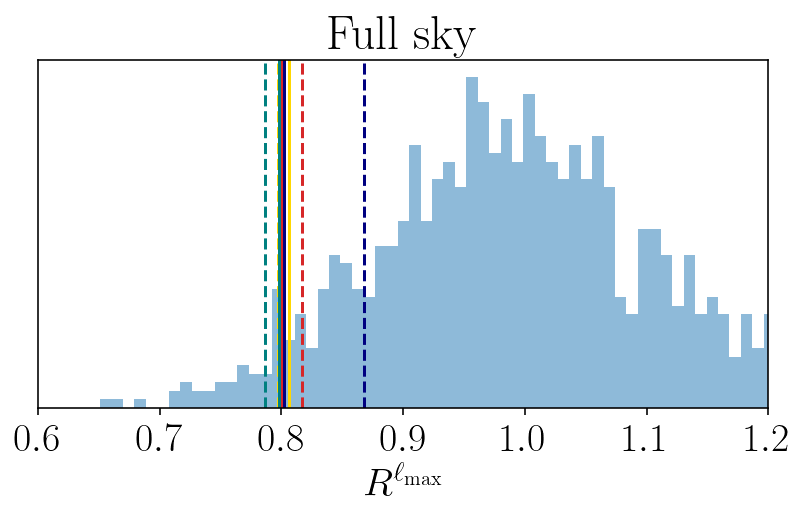

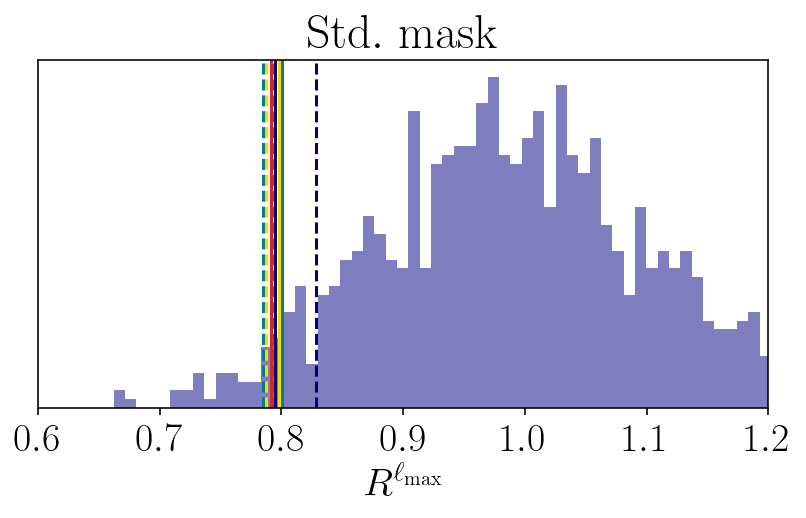

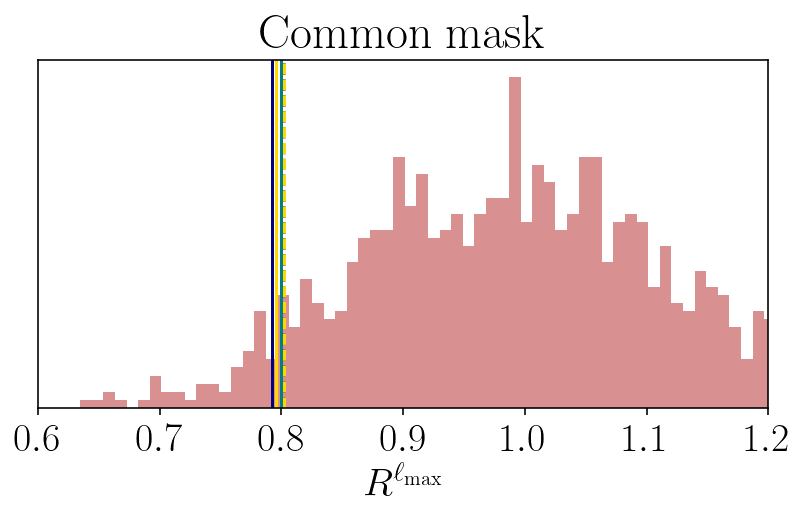

In [20]:
for m in range(Nmasks):
    plt.title(labels_mask[m])
    h=plt.hist(R_sims[m].T[27], bins=100, alpha=0.5, color=colors_mask[m])
    for n in range(Nmaps): plt.axvline(R_Planck[m][n][27], label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    plt.xlim(0.6, 1.2)
    plt.xlabel(r"$R^{\ell_\mathrm{max}}$")
    plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
    #plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("hist_Rlmax_"+names_mask[m]+".pdf", format="PDF")
    plt.show()

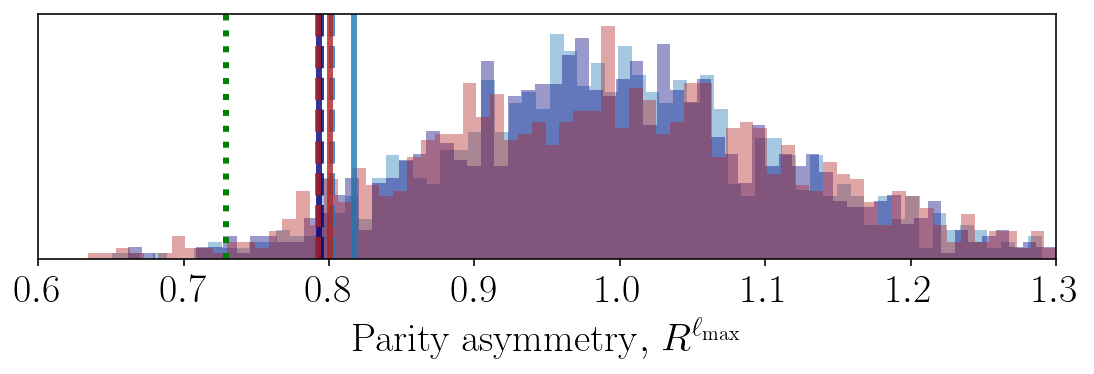

In [21]:
fig = plt.figure(figsize=(8, 3))
#plt.plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
#plt.plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    h=plt.hist(R_sims[m].T[27], bins=100, alpha=0.4, density=True, color=colors_mask[m])
    plt.axvline(R_Planck[m][index_Planck][27], color=colors_mask[m], alpha=0.8, lw=3, ls="-", label=labels_mask[m])
    plt.axvline(R_Planck[m][index_Hayley][27], color=colors_mask[m], alpha=0.8, lw=3, ls="--")
plt.axvline(R_Planck_qml[27], color=color_qml, label=label_qml, ls=":", lw=3)
plt.xlim(0.6, 1.3)
plt.xlabel(r"$\mathrm{Parity\ asymmetry,}\ R^{\ell_\mathrm{max}}$")
plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
#plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("hist_Rlmax.pdf", format="PDF")
plt.show()

In [22]:
for m in range(Nmasks):
    print("-----------")
    print(names_mask[m])
    for n in range(Nmaps):
        print(f"R_27 = {R_Planck[m][n][27]:.2f}, p-value: {100*p_Planck[m][n][27]:.2f}% ({names_Planck[n]})")

-----------
fullsky
R_27 = 0.82, p-value: 5.70% (commander_nside_128)
R_27 = 0.79, p-value: 2.70% (nilc_nside_128)
R_27 = 0.87, p-value: 13.40% (sevem_nside_128)
R_27 = 0.80, p-value: 3.90% (smica_nside_128)
R_27 = 0.80, p-value: 4.40% (v7_70GHz_nside_128)
R_27 = 0.80, p-value: 3.90% (v7_94GHz_nside_128)
R_27 = 0.80, p-value: 4.80% (v7_100GHz_nside_128)
R_27 = 0.81, p-value: 5.10% (v7_143GHz_nside_128)
-----------
stdmask
R_27 = 0.79, p-value: 3.40% (commander_nside_128)
R_27 = 0.78, p-value: 2.80% (nilc_nside_128)
R_27 = 0.83, p-value: 6.90% (sevem_nside_128)
R_27 = 0.79, p-value: 2.90% (smica_nside_128)
R_27 = 0.79, p-value: 3.30% (v7_70GHz_nside_128)
R_27 = 0.80, p-value: 3.80% (v7_94GHz_nside_128)
R_27 = 0.79, p-value: 3.40% (v7_100GHz_nside_128)
R_27 = 0.80, p-value: 3.70% (v7_143GHz_nside_128)
-----------
commask
R_27 = 0.80, p-value: 6.00% (commander_nside_128)
R_27 = 0.80, p-value: 6.00% (nilc_nside_128)
R_27 = 0.80, p-value: 6.20% (sevem_nside_128)
R_27 = 0.80, p-value: 6.10% 

## Compare to Jones++2023, $l_\mathrm{max} = 27$, full sky

$R^{TT} = 0.7896$, p-value: 3% (Commander)

$R^{TT} = 0.7448$, p-value: 1% (NILC)

$R^{TT} = 0.8194$, p-value: 5.4% (SEVEM)

$R^{TT} = 0.7906$, p-value: 3% (SMICA)

In [ ]:
print("p-values")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{100*p_Planck[m][n][27]:.2f} ", end="")
    print("\\\\")

In [ ]:
print("stats")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{R_Planck[m][n][27]:.2f} ", end="")
    print("\\\\")

# Tests

In [ ]:
for m in range(Nmasks):
    fig = plt.figure(figsize=(8, 5))
    for n in range(4,Nmaps):
        plt.plot(ll, ll*(ll+1)*cl_Planck[m][n]/(2*np.pi), label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    plt.plot(ll, dl_theory, label=r"$\mathrm{Theory}$", color="grey", ls="--")
    #plt.plot(ll, ll*(ll+1)*cl_qml/(2*np.pi), label=label_qml, color=color_qml, ls=":")
    #plt.fill_between(ll, ll*(ll+1)/(2*np.pi)*(mean_cls[m]-std_cls[m]),   ll*(ll+1)/(2*np.pi)*(mean_cls[m]+std_cls[m]),   alpha= 0.2, color=colors_mask[m])
    #plt.fill_between(ll, ll*(ll+1)/(2*np.pi)*(mean_cls[m]-2*std_cls[m]), ll*(ll+1)/(2*np.pi)*(mean_cls[m]+2*std_cls[m]), alpha= 0.2, color=colors_mask[m])
    plt.fill_between(ll, ll*(ll+1)/(2*np.pi)*perc_68_lower[m],   ll*(ll+1)/(2*np.pi)*perc_68_upper[m],   alpha= 0.2, color=colors_mask[m])
    plt.fill_between(ll, ll*(ll+1)/(2*np.pi)*perc_95_lower[m],   ll*(ll+1)/(2*np.pi)*perc_95_upper[m],   alpha= 0.2, color=colors_mask[m])
    plt.ylabel(r"$D_\ell\ [\mu K^2]$")
    plt.xlabel(r"$\ell$")
    #plt.xlim(2,30)
    plt.xlim(2,200)
    #plt.ylim(0,2000)
    plt.ylim(0,7000)
    plt.title(labels_mask[m])
    plt.legend(loc="lower right")
    plt.savefig(f"Cl_{names_mask[m]}.pdf", format="PDF")
    plt.show()

In [ ]:
for m in range(Nmasks):
    fig = plt.figure(figsize=(8, 5))
    n=5
    plt.plot(ll, cl_Planck[m][n]/cl_Planck[m][6]-1, label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    n=4
    plt.plot(ll, cl_Planck[m][n]/cl_Planck[m][6]-1, label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    n=7
    plt.plot(ll, cl_Planck[m][n]/cl_Planck[m][6]-1, label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    
    #plt.plot(ll, dl_theory, label=r"$\mathrm{Theory}$", color="grey", ls="--")
    #plt.plot(ll, ll*(ll+1)*cl_qml/(2*np.pi), label=label_qml, color=color_qml, ls=":")
    #plt.fill_between(ll, ll*(ll+1)/(2*np.pi)*(mean_cls[m]-std_cls[m]),   ll*(ll+1)/(2*np.pi)*(mean_cls[m]+std_cls[m]),   alpha= 0.2, color=colors_mask[m])
    #plt.fill_between(ll, ll*(ll+1)/(2*np.pi)*(mean_cls[m]-2*std_cls[m]), ll*(ll+1)/(2*np.pi)*(mean_cls[m]+2*std_cls[m]), alpha= 0.2, color=colors_mask[m])
    plt.ylabel(r"$D_\ell/D_\ell^{100GHz}-1$")
    plt.xlabel(r"$\ell$")
    plt.axhline(0)
    plt.axhline(0.025)
    #plt.xlim(2,30)
    plt.xlim(2,200)
    #plt.ylim(0,2000)
    #plt.ylim(0,7000)
    plt.ylim(-0.1,0.1)
    plt.title(labels_mask[m])
    plt.legend(loc="lower right")
    plt.savefig(f"Cl_{names_mask[m]}.pdf", format="PDF")
    plt.show()